**Part 1**

I used copilot to help me with coding as I have not had time to learn python yet.

Import necessary libraries and load the data:

In [3]:
import kagglehub
import nltk
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import MultiLabelBinarizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import os

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

path = kagglehub.dataset_download("PromptCloudHQ/imdb-data")
csv_file_path = os.path.join(path, 'IMDB-Movie-Data.csv') # Ensure this is the correct filename
data = pd.read_csv(csv_file_path)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Text preprocessing:

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = nltk.word_tokenize(text.lower())
    filtered_tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and token.isalnum()]
    return " ".join(filtered_tokens)

data['cleaned_description'] = data['Description'].apply(preprocess_text)

Label preprocessing:

In [8]:
genres = data['Genre'].apply(lambda x: x.split(','))
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(genres)

Tokenization and padding:

In [9]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(data['cleaned_description'])
sequences = tokenizer.texts_to_sequences(data['cleaned_description'])
padded_sequences = pad_sequences(sequences, maxlen=100)

Download and load GloVe embeddings:

In [10]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print('Found %s word vectors.' % len(embeddings_index))

--2024-11-07 04:37:35--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2024-11-07 04:37:35--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2024-11-07 04:37:36--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

Create embedding matrix:

In [11]:
embedding_dim = 100
word_index = tokenizer.word_index
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

Build the RNN model:

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=len(word_index) + 1, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False))
rnn_model.add(SimpleRNN(128, activation='relu'))
rnn_model.add(Dense(20, activation='sigmoid'))

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Build the LSTM model:

In [14]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=len(word_index) + 1, output_dim=embedding_dim, weights=[embedding_matrix], input_length=100, trainable=False))
lstm_model.add(LSTM(128, activation='relu'))
lstm_model.add(Dense(20, activation='sigmoid'))

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Split the dataset:

In [15]:
X_train, X_val, X_test = padded_sequences[:700], padded_sequences[700:800], padded_sequences[800:]
y_train, y_val, y_test = genres_encoded[:700], genres_encoded[700:800], genres_encoded[800:]

Train the RNN model:

In [16]:
rnn_history = rnn_model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.0704 - loss: 0.5639 - val_accuracy: 0.1600 - val_loss: 0.3398
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1933 - loss: 0.3290 - val_accuracy: 0.1800 - val_loss: 0.3261
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2416 - loss: 0.3152 - val_accuracy: 0.1800 - val_loss: 0.3233
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2816 - loss: 0.3031 - val_accuracy: 0.1900 - val_loss: 0.3208
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2766 - loss: 0.2890 - val_accuracy: 0.2400 - val_loss: 0.3071
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3274 - loss: 0.2765 - val_accuracy: 0.2400 - val_loss: 0.3093
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3588 - loss: 0.2555 - val_accuracy: 0.3100 - val_loss: 0.3066
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4098 - loss: 0.2436 - val_accuracy: 0.2600 - v

Train the LSTM model:

In [17]:
lstm_history = lstm_model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val))

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.1031 - loss: 0.5974 - val_accuracy: 0.1400 - val_loss: 0.4399
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.2031 - loss: 0.3964 - val_accuracy: 0.1600 - val_loss: 0.3383
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - accuracy: 0.2535 - loss: 0.3251 - val_accuracy: 0.2600 - val_loss: 0.3220
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.3585 - loss: 0.3037 - val_accuracy: 0.2000 - val_loss: 0.3141
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.3528 - loss: 0.2883 - val_accuracy: 0.2400 - val_loss: 0.3117
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.3611 - loss: 0.2767 - val_accuracy: 0.2300 - val_loss: 0.3017
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - accuracy: 0.4103 - loss: 0.2663 - val_accuracy: 0.2100 - val_loss: 0.2962
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.3636 - loss: 0.2519 - val_accuracy: 0.

Plot training and validation loss/accuracy:

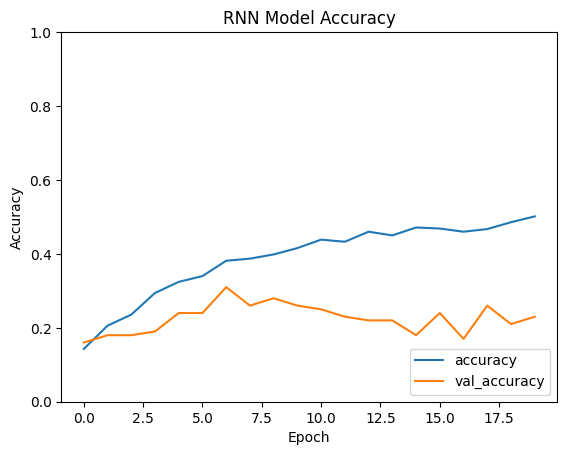

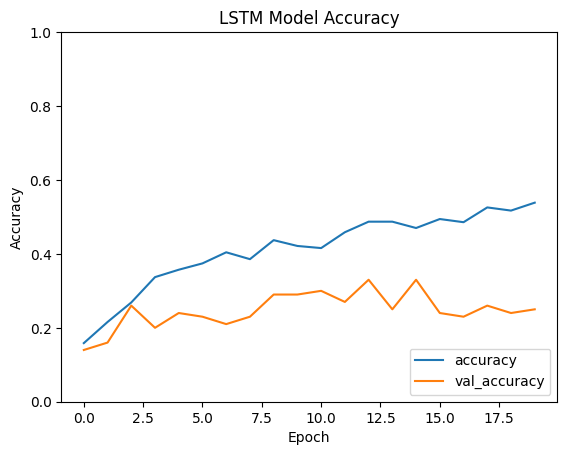

In [18]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()

plot_history(rnn_history, "RNN Model Accuracy")
plot_history(lstm_history, "LSTM Model Accuracy")

Evaluate on test set:

In [19]:
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(X_test, y_test)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test, y_test)

print(f'RNN Model Test Accuracy: {rnn_test_acc}')
print(f'LSTM Model Test Accuracy: {lstm_test_acc}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2674 - loss: 0.3414
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3550 - loss: 0.3121
RNN Model Test Accuracy: 0.25
LSTM Model Test Accuracy: 0.3400000035762787


Combine titles with descriptions:

In [20]:
data['title_description'] = data['Title'] + " " + data['cleaned_description']
sequences_with_titles = tokenizer.texts_to_sequences(data['title_description'])
padded_sequences_with_titles = pad_sequences(sequences_with_titles, maxlen=100)

Train enhanced model:

In [21]:
X_train_titles, X_val_titles, X_test_titles = padded_sequences_with_titles[:700], padded_sequences_with_titles[700:800], padded_sequences_with_titles[800:]

rnn_history_with_titles = rnn_model.fit(X_train_titles, y_train, epochs=20, validation_data=(X_val_titles, y_val))

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4768 - loss: 0.1039 - val_accuracy: 0.2400 - val_loss: 0.3531
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.4993 - loss: 0.0918 - val_accuracy: 0.2300 - val_loss: 0.3709
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5222 - loss: 0.0876 - val_accuracy: 0.2100 - val_loss: 0.3835
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4884 - loss: 0.0770 - val_accuracy: 0.2000 - val_loss: 0.4102
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.4955 - loss: 0.0660 - val_accuracy: 0.2300 - val_loss: 0.3930
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.5095 - loss: 0.0577 - val_accuracy: 0.2300 - val_loss: 0.4110
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.5295 - loss: 0.0576 - val_accuracy: 0.2500 - val_loss: 0.4523
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5211 - loss: 0.0516 - val_accuracy: 0.1900 - v

Evaluate enhanced model:

In [22]:
rnn_test_loss_titles, rnn_test_acc_titles = rnn_model.evaluate(X_test_titles, y_test)
print(f'Enhanced RNN Model Test Accuracy with Titles: {rnn_test_acc_titles}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2491 - loss: 0.5979
Enhanced RNN Model Test Accuracy with Titles: 0.25


The LSTM model is able to understand and retain important information that the RNN cannot. This allows the model to have grater accuracy, in this case improving by approximately 9 percent.

**Part 2**

Download and Prepare the Data:

In [9]:
import kagglehub
import os

# Download the dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


Load and Preprocess Images:

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define directories
train_dir = '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train'
val_dir = '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_test/seg_test'

# Create ImageDataGenerator instances for training and validation
train_datagen = ImageDataGenerator(rescale=1.0/255.0)
val_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Model 1: CNN with 3 Conv layers and 3 Max-Pooling layers:

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input

model1 = Sequential([
    Input(shape=(150, 150, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(6, activation='softmax')
])

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model 2: CNN with 6 Conv layers and 3 Pooling layers:

In [12]:
model2 = Sequential([
    Input(shape=(150, 150, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(6, activation='softmax')
])

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Train Model 1:

In [13]:
history1 = model1.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=20
)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


438/438 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.5156 - loss: 1.2930 - val_accuracy: 0.7480 - val_loss: 0.6837
Epoch 2/20
  1/438 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.8125 - loss: 0.4799

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8125 - loss: 0.4799 - val_accuracy: 0.7083 - val_loss: 0.9973
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.7466 - loss: 0.6676 - val_accuracy: 0.7288 - val_loss: 0.7147
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6875 - loss: 0.8345 - val_accuracy: 0.6250 - val_loss: 0.9315
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8211 - loss: 0.4900 - val_accuracy: 0.8239 - val_loss: 0.5135
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 53us/step - accuracy: 0.8125 - loss: 0.5362 - val_accuracy: 0.7917 - val_loss: 0.3733
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.8667 - loss: 0.3770 - val_accuracy: 0.8327 - val_loss: 0.4958
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 44us/step - accuracy: 0.8750 - loss: 0.3428 - val_accuracy: 0.7083 - val_loss: 1.1047
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9017 - loss: 0.2715 - val_accuracy: 0.7

Train Model 2:

In [14]:
history2 = model2.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=20
)

Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 46s 82ms/step - accuracy: 0.4544 - loss: 1.3247 - val_accuracy: 0.5978 - val_loss: 0.9572
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6250 - loss: 1.0341 - val_accuracy: 0.6667 - val_loss: 0.9900
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.6562 - loss: 0.8351 - val_accuracy: 0.7120 - val_loss: 0.7427
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7188 - loss: 0.6502 - val_accuracy: 0.7500 - val_loss: 0.7641
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.7588 - loss: 0.6348 - val_accuracy: 0.7893 - val_loss: 0.5711
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7812 - loss: 0.4200 - val_accuracy: 0.7917 - val_loss: 0.5332
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8072 - loss: 0.5213 - val_accuracy: 0.7913 - val_loss: 0.5512
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 57us/step - accuracy: 0.7812 - loss: 0.5617 - val_acc

Calculate Accuracy:

In [15]:
val_loss1, val_acc1 = model1.evaluate(val_generator)
val_loss2, val_acc2 = model2.evaluate(val_generator)

print(f'Model 1 Validation Accuracy: {val_acc1}')
print(f'Model 2 Validation Accuracy: {val_acc2}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8006 - loss: 0.9441
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8394 - loss: 0.5470
Model 1 Validation Accuracy: 0.8180000185966492
Model 2 Validation Accuracy: 0.8386666774749756


Calculate Per-Class Accuracy for Model 1:

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Generate predictions for the validation set using the entire dataset
val_steps = val_generator.samples // val_generator.batch_size + (1 if val_generator.samples % val_generator.batch_size else 0)
val_predictions_model1 = model1.predict(val_generator, steps=val_steps)

# Get true labels
val_true_labels = val_generator.classes

# Get predicted labels by taking the argmax of the predictions
val_pred_labels_model1 = np.argmax(val_predictions_model1, axis=1)

# Generate a confusion matrix
conf_matrix_model1 = confusion_matrix(val_true_labels, val_pred_labels_model1)

# Calculate per-class accuracy for Model 1
class_accuracies_model1 = {}
for i in range(len(val_generator.class_indices)):
    class_total = np.sum(conf_matrix_model1[i, :])
    class_correct = conf_matrix_model1[i, i]
    class_accuracies_model1[i] = class_correct / class_total

# Print per-class accuracy for Model 1
for class_index, accuracy in class_accuracies_model1.items():
    class_label = list(val_generator.class_indices.keys())[class_index]
    print(f'Model 1 Accuracy for class {class_label}: {accuracy:.4f}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step
Model 1 Accuracy for class buildings: 0.1968
Model 1 Accuracy for class forest: 0.1688
Model 1 Accuracy for class glacier: 0.1790
Model 1 Accuracy for class mountain: 0.1543
Model 1 Accuracy for class sea: 0.2392
Model 1 Accuracy for class street: 0.1796


Calculate Per-Class Accuracy for Model 2:

In [25]:
# Generate predictions for the validation set using the entire dataset
val_predictions_model2 = model2.predict(val_generator, steps=val_steps)

# Get predicted labels by taking the argmax of the predictions
val_pred_labels_model2 = np.argmax(val_predictions_model2, axis=1)

# Generate a confusion matrix
conf_matrix_model2 = confusion_matrix(val_true_labels, val_pred_labels_model2)

# Calculate per-class accuracy for Model 2
class_accuracies_model2 = {}
for i in range(len(val_generator.class_indices)):
    class_total = np.sum(conf_matrix_model2[i, :])
    class_correct = conf_matrix_model2[i, i]
    class_accuracies_model2[i] = class_correct / class_total

# Print per-class accuracy for Model 2
for class_index, accuracy in class_accuracies_model2.items():
    class_label = list(val_generator.class_indices.keys())[class_index]
    print(f'Model 2 Accuracy for class {class_label}: {accuracy:.4f}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step
Model 2 Accuracy for class buildings: 0.1373
Model 2 Accuracy for class forest: 0.1751
Model 2 Accuracy for class glacier: 0.1917
Model 2 Accuracy for class mountain: 0.1771
Model 2 Accuracy for class sea: 0.1765
Model 2 Accuracy for class street: 0.1796


Summary of Findings:

Class | Model 1 Accuracy | Model 2 Accuracy
-------------------|---------|------
Buildings | 0.1968 | 0.1373
Forest | 0.1688 | 0.1751
Glacier | 0.1790 | 0.1917
Mountain | 0.1543 | 0.1771
Sea | 0.2392 | 0.1765
Street | 0.1796 | 0.1796

Buildings: Model 1 outperformed Model 2 with an accuracy of 0.1968 compared to 0.1373.

Forest: Model 2 slightly outperformed Model 1 with an accuracy of 0.1751 compared to 0.1688.

Glacier: Model 2 showed better performance with an accuracy of 0.1917 compared to Model 1's 0.1790.

Mountain: Model 2 again outperformed Model 1, achieving an accuracy of 0.1771 compared to 0.1543.

Sea: Model 1 had a higher accuracy of 0.2392 compared to Model 2's 0.1765.

Street: Both models achieved the same accuracy of 0.1796.

Total Accuracy:

Model 1: Achieved a total validation accuracy of 0.8180.

Model 2: Achieved a higher total validation accuracy of 0.8387.

Conclusion: Model 2 generally outperformed Model 1 in total validation accuracy and in several per-class accuracies. The added complexity of Model 2 with additional convolutional layers allowed it to better capture and learn the features of different classes, resulting in higher overall performance. However, Model 1 showed better performance in classifying Sea and Buildings, indicating that Model 1 might better capture specific nuances of these classes.

Visualize predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step


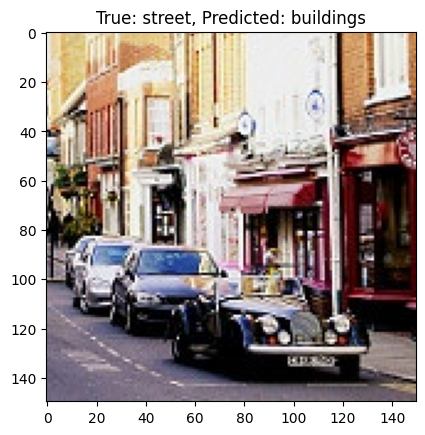

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


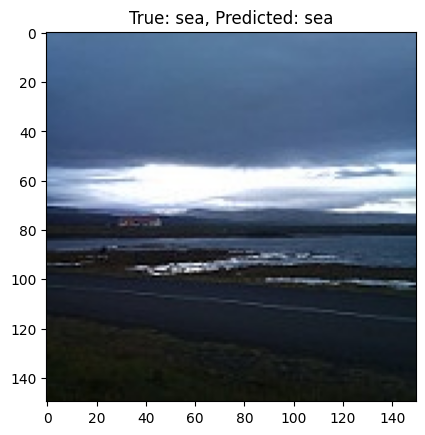

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


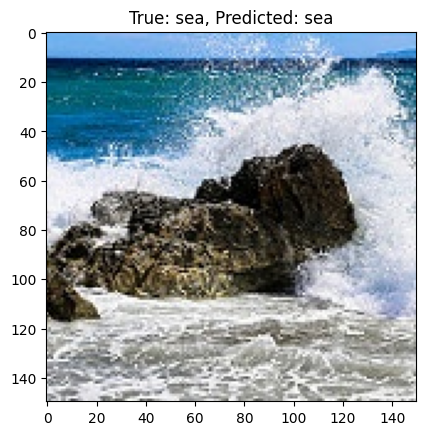

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


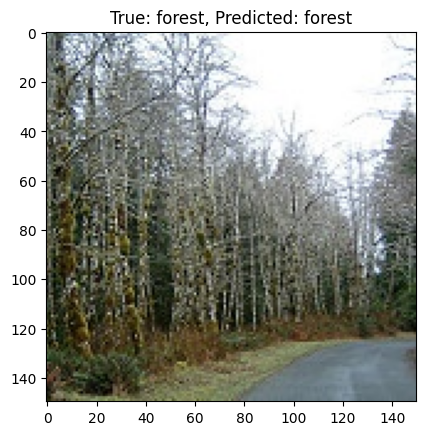

In [18]:
import numpy as np
import random

# Function to display predictions
def display_predictions(model, generator):
    for i in range(2):
        img, true_label = next(generator)
        pred_label = np.argmax(model.predict(img), axis=-1)

        plt.imshow(img[0])
        true_class = generator.class_indices
        true_class = dict((v,k) for k,v in true_class.items())
        true_class_label = true_class[np.argmax(true_label[0])]
        pred_class_label = true_class[pred_label[0]]

        plt.title(f"True: {true_class_label}, Predicted: {pred_class_label}")
        plt.show()

display_predictions(model1, val_generator)
display_predictions(model2, val_generator)